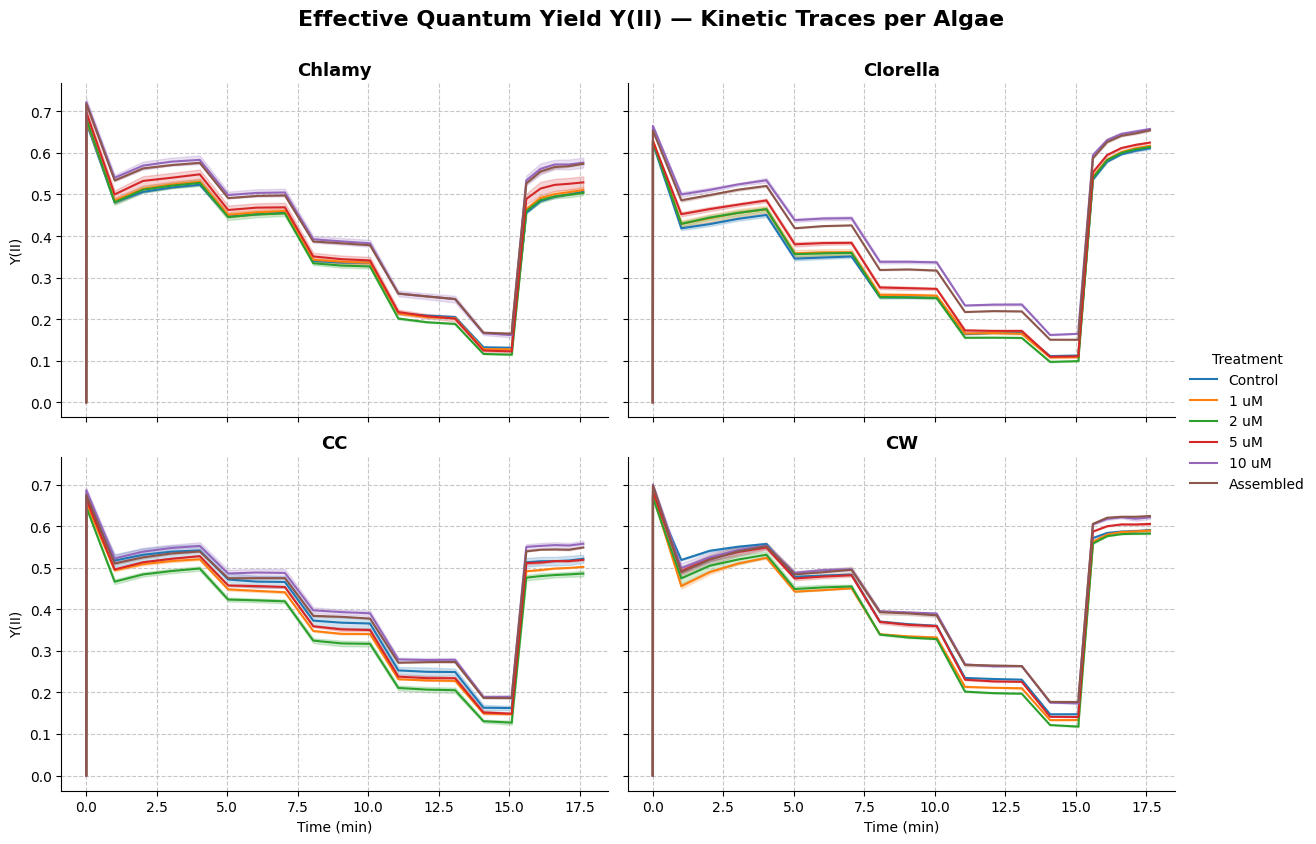

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# 1. GLOBAL CONFIGURATION
# ─────────────────────────────────────────────
EXCEL_FILE = "Your_excel_name.xlsx"
SHEET_NAME = "Your_sheet_name"  
SAVE_PLOTS = False
COLUMNS_PER_ROW   = 2  # Change to 3 or 4 to automatically rearrange the grid layout
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 2. DATA INGESTION & HIERARCHICAL PARSING
# ─────────────────────────────────────────────
df = pd.read_excel(EXCEL_FILE, sheet_name=SHEET_NAME, header=0)

df["Time(min)"] = df["Time"] / 60000
df = df.drop(columns=["Time"])

data_melted = df.melt(id_vars=["Time(min)"], var_name="Raw_Condition", value_name="Y(II)")

# Clean replicate tags
data_melted["Group"] = data_melted["Raw_Condition"].str.replace(r'_[\d\.]+$', '', regex=True)

# Split into Algae and Treatment at the first underscore
data_melted[["Algae", "Treatment"]] = data_melted["Group"].str.split('_', n=1, expand=True)
data_melted["Treatment"] = data_melted["Treatment"].str.replace('_', ' ')

unique_treatments = data_melted["Treatment"].unique()
unique_algae = data_melted["Algae"].unique()

# Generate procedural palette
colours = sns.color_palette("tab10", len(unique_treatments))
palette = dict(zip(unique_treatments, colours))

# ─────────────────────────────────────────────
# 3. AUTOMATED VISUALISATION (DYNAMIC GRID)
# ─────────────────────────────────────────────
# The layout adjusts automatically based on unique_algae and COLUMNS_PER_ROW
g = sns.relplot(
    data=data_melted, x="Time(min)", y="Y(II)",
    col="Algae",         
    hue="Treatment",     
    col_wrap=COLUMNS_PER_ROW,  # Dynamically sets grid width; rows auto-calculate
    kind="line",
    errorbar="sd",       
    height=4, aspect=1.5,
    palette=palette, linewidth=1.5
)

g.fig.suptitle("Effective Quantum Yield Y(II) — Kinetic Traces per Algae", fontsize=16, fontweight='bold', y=1.05)

for ax in g.axes.flat:
    clean_title = ax.get_title().split("=")[-1].strip()
    ax.set_title(clean_title, fontweight='bold', fontsize=13)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Y(II)")
    ax.grid(True, linestyle='--', alpha=0.7)

if SAVE_PLOTS:
    safe_filename = 'YII_Kinetic_Species_Grid.svg'
    g.fig.savefig(safe_filename, dpi=1200, bbox_inches='tight')
    print(f"Saved {safe_filename}")
else:
    plt.show()

plt.close()